In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:

# # 1. LOAD KAGGLE DATA 
# # Note: Kaggle/PhysioNet data often comes in individual .psv files per patient.
# # This block combines them into a single dataframe.
# path = 'path_to_your_data/*.psv' # Update this to your folder
# all_files = glob.glob(path)

# li = []
# for filename in all_files:
#     df_temp = pd.read_csv(filename, sep='|')
#     # Add Patient ID from filename
#     df_temp['Patient_ID'] = filename.split('/')[-1].split('.')[0]
#     li.append(df_temp)

# df = pd.concat(li, axis=0, ignore_index=True)

input_path = r'D:\Uni\Year_3_sem_2\XAI\Project\phase_2\Dataset.csv'
df = pd.read_csv(input_path)

# 2. APPLY PAPER'S INCLUSION CRITERIA
# The paper excludes admissions < 3 hours to ensure enough sequence data exists.
patient_lengths = df.groupby('Patient_ID')['ICULOS'].max()
valid_patients = patient_lengths[patient_lengths >= 3].index
df = df[df['Patient_ID'].isin(valid_patients)]

print(f"Total Patients after filtering: {len(df['Patient_ID'].unique())}")

Total Patients after filtering: 40336


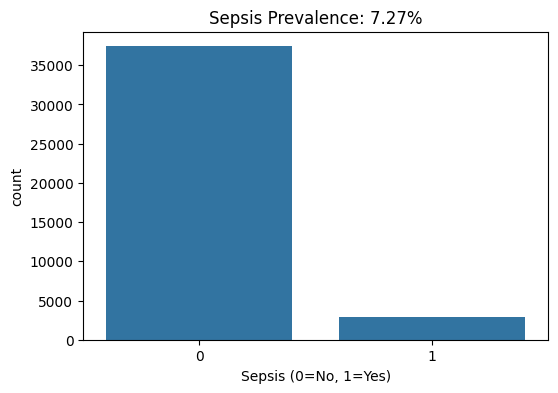

In [3]:
# 3. CLASS IMBALANCE (Paper Section 3.1)
# Calculate prevalence based on patients, not rows.
sepsis_status = df.groupby('Patient_ID')['SepsisLabel'].max()
prevalence = sepsis_status.mean() * 100

plt.figure(figsize=(6, 4))
sns.countplot(x=sepsis_status)
plt.title(f'Sepsis Prevalence: {prevalence:.2f}%')
plt.xlabel('Sepsis (0=No, 1=Yes)')
plt.show()

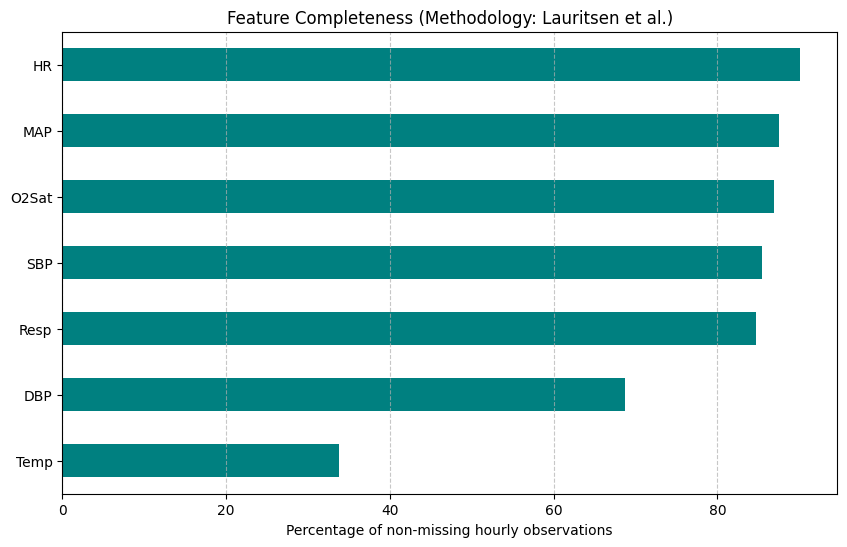

In [4]:
# 4. DATA COMPLETENESS (Paper Section 3.2)
# The paper analyzes how often vitals are recorded.
vitals = ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp']
completeness = df[vitals].notnull().mean().sort_values() * 100

plt.figure(figsize=(10, 6))
completeness.plot(kind='barh', color='teal')
plt.title('Feature Completeness (Methodology: Lauritsen et al.)')
plt.xlabel('Percentage of non-missing hourly observations')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

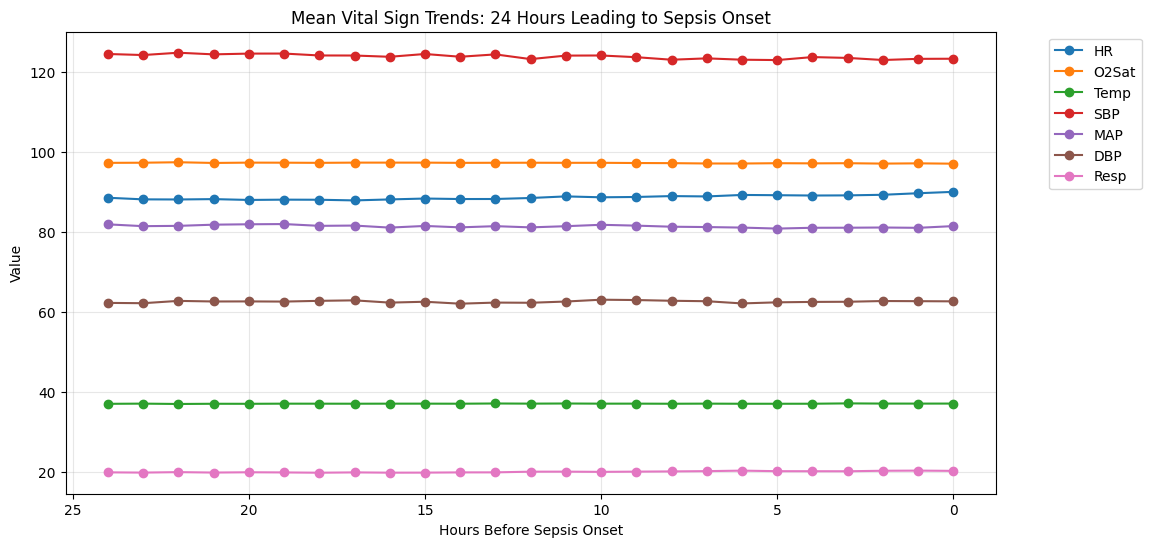

In [5]:
# 5. TEMPORAL TRENDS BEFORE ONSET (Paper Section 4.2)
# The paper visualizes vitals leading up to the sepsis event.
sepsis_patients = df[df['SepsisLabel'] == 1]['Patient_ID'].unique()
df_pos = df[df['Patient_ID'].isin(sepsis_patients)].copy()

# Find the first hour where SepsisLabel becomes 1
onset_hour = df_pos[df_pos['SepsisLabel'] == 1].groupby('Patient_ID')['ICULOS'].min().reset_index()
onset_hour.columns = ['Patient_ID', 'Onset_Time']

df_pos = df_pos.merge(onset_hour, on='Patient_ID')
df_pos['Hours_Before_Onset'] = df_pos['Onset_Time'] - df_pos['ICULOS']

# Filter for 24 hours prior to onset (The Paper's "Lookback" window)
pre_sepsis = df_pos[(df_pos['Hours_Before_Onset'] >= 0) & (df_pos['Hours_Before_Onset'] <= 24)]
temporal_means = pre_sepsis.groupby('Hours_Before_Onset')[vitals].mean()

plt.figure(figsize=(12, 6))
for col in vitals:
    plt.plot(temporal_means.index, temporal_means[col], label=col, marker='o')

plt.gca().invert_xaxis() # Move toward zero (Onset)
plt.title('Mean Vital Sign Trends: 24 Hours Leading to Sepsis Onset')
plt.xlabel('Hours Before Sepsis Onset')
plt.ylabel('Value')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

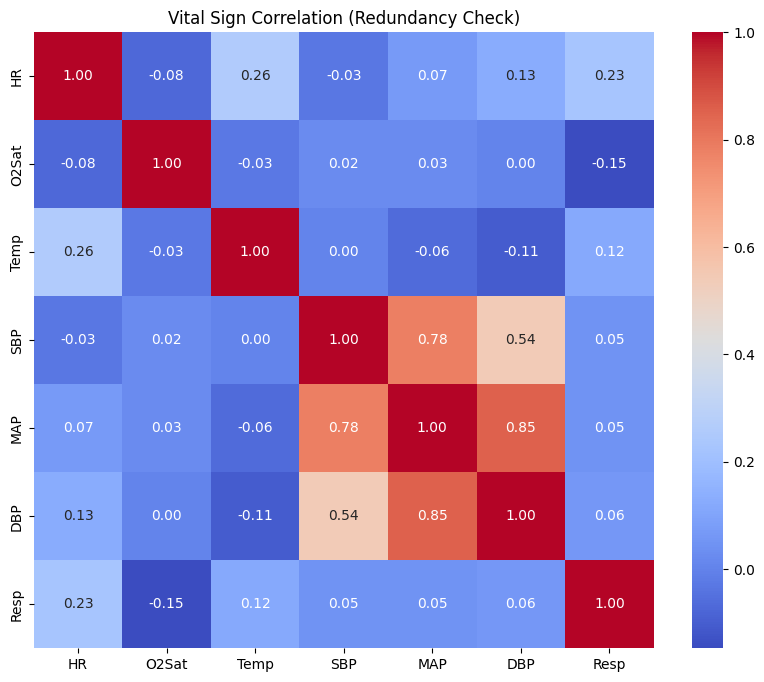

In [7]:
# 6. FEATURE CORRELATION (Paper Section 3.2)
# Checks if SBP, DBP, and MAP are redundant.
plt.figure(figsize=(10, 8))
sns.heatmap(df[vitals].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Vital Sign Correlation (Redundancy Check)')
plt.show()

# # 7. EXPORT FOR MODELING
# # Save the filtered and cleaned long-form data
df.to_parquet('processed_kaggle_sepsis.parquet', index=False)